# Profit-Optimized Credit Decisioning Engine — walkthrough

**Business question:** if we ran credit policy for LendingClub's 36-month loans, which applicants should we approve to maximize profit, and how much better is a data-driven policy than LendingClub's own grade-based one?

This notebook walks through every phase of the project and shows its results. It **does not retrain anything**:
the pipeline (`python -m credit_engine.run_all`) writes every number to `reports/metrics/` and every chart to `reports/figures/`, and this notebook reads them.
Cells marked *live SQL* query the local DuckDB database when it exists.

| Phase | What |
|---|---|
| 1–2 | SQL: clean 2.26M loans, define the population, vintage analysis |
| 3–4 | Features, leakage control, out-of-time splits |
| 5 | Models: LendingClub grade vs WoE scorecard vs LightGBM |
| 6 | Profit decision layer: which policy makes the most money |
| 7 | Loss forecast vs actual |
| 8 | Drift monitoring, weak spots, explainability |

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from credit_engine.config import load_config
from credit_engine.data import query, table_exists

cfg = load_config()
METRICS, FIGURES = cfg["paths"]["metrics_dir"], cfg["paths"]["figures_dir"]
LIVE_SQL = table_exists(cfg, "loans_clean")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def metrics(name):
    return json.loads((METRICS / name).read_text(encoding="utf-8"))

def show(fig):
    display(Image(filename=str(FIGURES / fig)))

print("Live SQL available:", LIVE_SQL)

Live SQL available: True


## Phase 1 — Load, clean, define the population (SQL)

DuckDB reads the 2.2M-row gzipped CSV directly (never pandas), keeps ~50 of 151 columns and casts them with `TRY_CAST`, so malformed rows become NULL instead of crashing the load.

**Population:** 36-month, individual applications issued 2010–2015 with a **final outcome**. A Dec-2015 loan matures in Dec-2018, just before the data ends, so every loan has had its full life.
**Target:** 1 = Charged Off / Default, 0 = Fully Paid.

In [2]:
summary = metrics("data_summary.json")
display(pd.DataFrame(summary["population_waterfall"]))
print(f"Modeling population: {summary['n_loans']:,} loans, default rate {summary['overall_default_rate']:.1%}")
print("Payment identity check (total_pymnt = principal + interest + fees + recoveries):", summary["payment_identity"])

,step,n_loans
0,all rows in file,2260701
1,valid id and loan amount,2260668
2,36-month term,1609754
3,individual application,1539983
4,issued 2010-01-01 to 2015-12-01,612653
5,de-duplicated on id,612653
6,final outcome known (modeling population),611816


Modeling population: 611,816 loans, default rate 13.9%
Payment identity check (total_pymnt = principal + interest + fees + recoveries): {'n_loans': 611816.0, 'share_within_1_usd': 1.0, 'mean_abs_gap_usd': 0.001445, 'p99_abs_gap_usd': 0.004913, 'max_abs_gap_usd': 0.01}


Loans without a final outcome (still *Current* / *Late*) are dropped. If many recent loans were still running, that would bias the recent vintages, so each quarter is checked against a 2% threshold:

In [3]:
excl = pd.DataFrame(summary["exclusions_by_quarter"])
display(excl[["issue_quarter", "n_population", "n_kept", "n_not_final", "n_legacy", "pct_not_final"]].tail(4))
print("Quarters above the 2% flag:", summary["quarters_flagged_over_2pct_not_final"] or "none")

,issue_quarter,n_population,n_kept,n_not_final,n_legacy,pct_not_final
20,2015-01-01,56569,56568,1,0,0.0018
21,2015-04-01,64222,64222,0,0,0.0000
22,2015-07-01,73572,73567,5,0,0.0068
23,2015-10-01,88571,88430,141,0,0.1592


Quarters above the 2% flag: none


*Live SQL:* default rate by issue year straight from DuckDB.

In [4]:
if LIVE_SQL:
    display(query(cfg, '''
        SELECT year(issue_date) AS issue_year, COUNT(*) AS n_loans,
               ROUND(AVG(target), 4) AS default_rate, ROUND(AVG(int_rate), 2) AS avg_int_rate
        FROM loans_clean GROUP BY 1 ORDER BY 1'''))
else:
    display(pd.DataFrame(summary["rows_and_default_rate_by_year"]))

,issue_year,n_loans,default_rate,avg_int_rate
0,2010,8466,0.0995,11.0900
1,2011,14101,0.1063,10.5500
2,2012,43470,0.1358,12.6300
3,2013,100422,0.1233,13.3700
4,2014,162570,0.1373,12.4700
5,2015,282787,0.1488,11.2700


## Phase 2 — Vintage analysis (SQL)

A **vintage** is a cohort of loans issued in the same quarter. Three standard credit-risk views:
1. default rate by vintage × grade,
2. is risk priced correctly (interest rate vs realized default by sub-grade)?
3. cumulative default curves, built with a SQL **window function**.

In [5]:
sql = (ROOT / "sql" / "03_vintage.sql").read_text(encoding="utf-8")
print(sql[sql.index("-- 3."):])

-- 3. Cumulative default curve by vintage (window function).
-- APPROXIMATION: the data has no default date, so for a charged-off loan
-- months-on-book at default ~ months from issue to its last payment (0 if it never paid).
-- A full vintage x month grid is built so months with no new defaults still appear.
CREATE OR REPLACE TABLE vintage_cum_default AS
WITH base AS (
    SELECT date_trunc('quarter', issue_date)                                       AS vintage,
           LEAST(COALESCE(date_diff('month', issue_date, last_pymnt_date), 0), 60) AS mob,
           target
    FROM loans_clean
),
sizes AS (
    SELECT vintage, COUNT(*) AS n_loans FROM base GROUP BY 1
),
new_defaults AS (
    SELECT vintage, mob, SUM(target) AS new_defaults
    FROM base WHERE target = 1
    GROUP BY 1, 2
),
grid AS (
    SELECT s.vintage, m.mob, s.n_loans
    FROM sizes s CROSS JOIN range(0, 61) AS m(mob)
)
SELECT g.vintage,
       g.mob,
       g.n_loans,
       SUM(COALESCE(nd.new_defaults, 0)) OVER (PA

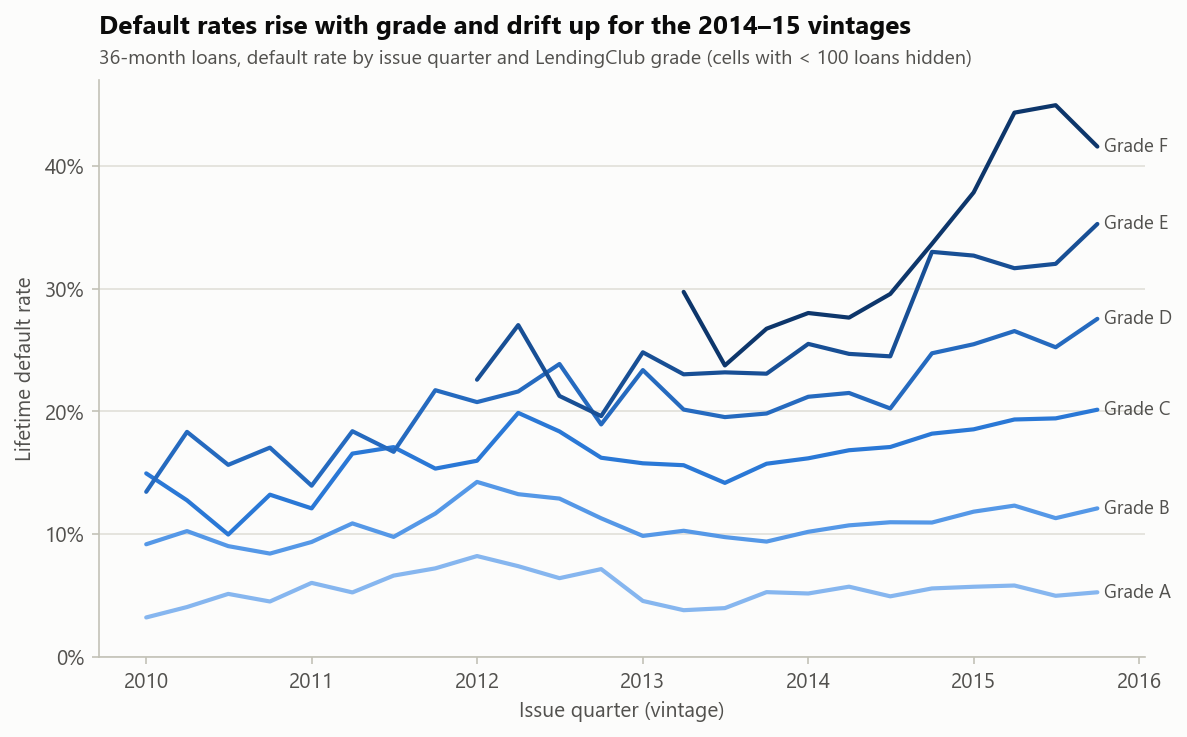

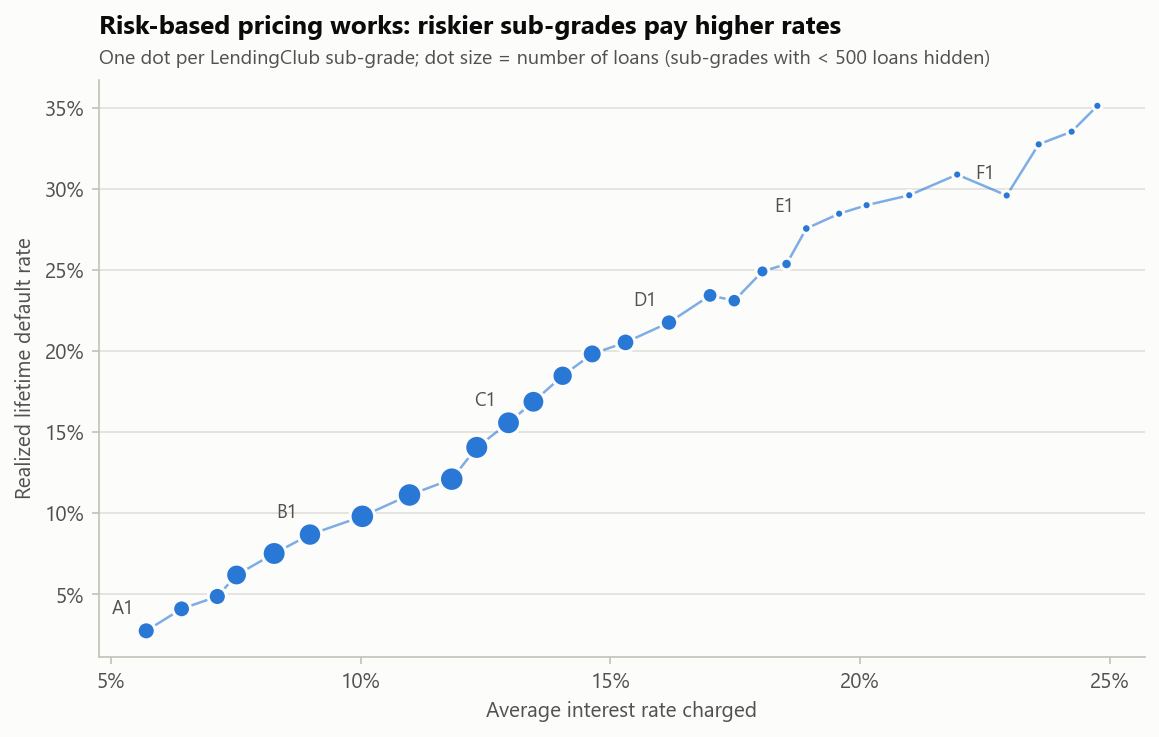

Spearman correlation, interest rate vs realized default rate across sub-grades: 0.986


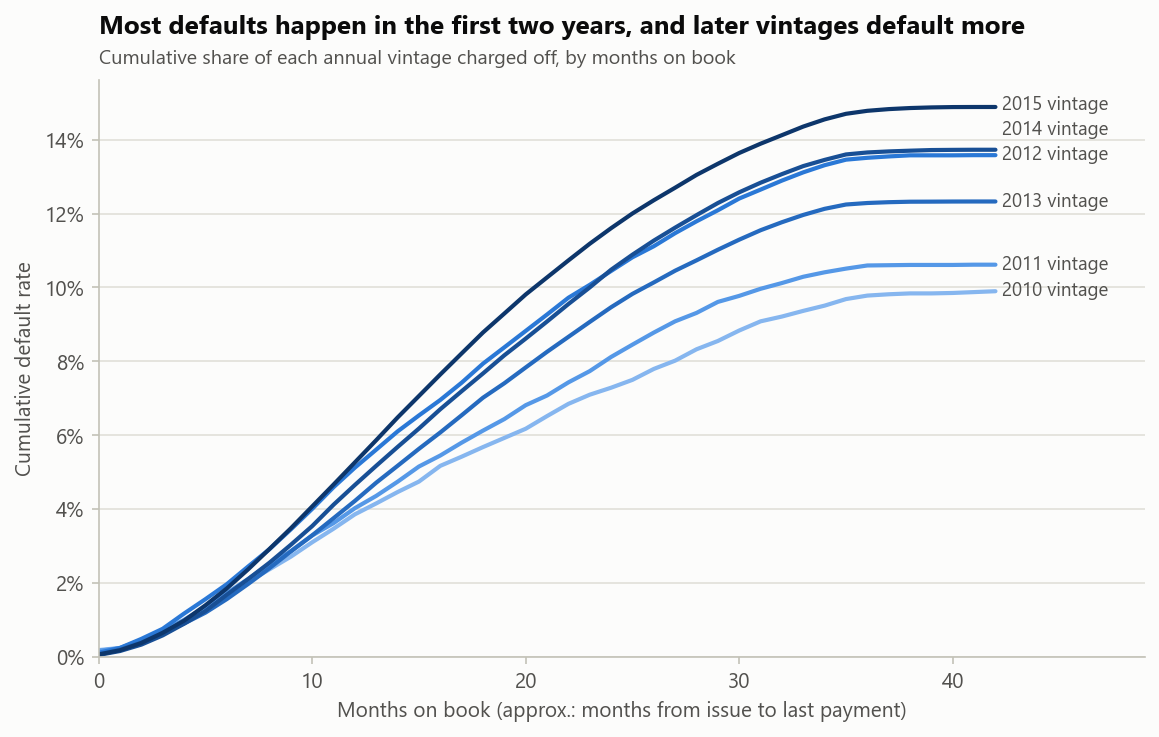

In [6]:
show("vintage_default_by_grade.png")
show("pricing_vs_risk.png")
print("Spearman correlation, interest rate vs realized default rate across sub-grades:",
      round(metrics("vintage_summary.json")["spearman_int_rate_vs_default_rate_by_subgrade"], 3))
show("cum_default_curves.png")

**Takeaways:** pricing tracks risk almost perfectly across sub-grades, but default rates rise *within* every grade in 2014–15.
The test period is riskier than the training period, which makes the out-of-time test harder, and realistic.

## Phases 3–4 — Features, leakage control, out-of-time splits

Only information available **at application time** may reach a model (an allowlist). Three groups are excluded:
- **post-origination fields** (payments, recoveries, later FICO pulls): classic leakage;
- **LendingClub's pricing** (`grade`, `sub_grade`, `int_rate`, `installment`): it *is* LC's risk model, so it is used for the benchmark and the profit math, never as a feature;
- **fair-lending proxies** (`zip_code`, `addr_state`, free-text job titles), per ECOA / Reg B.

A guard function raises an error if any of them reaches a feature matrix:

In [7]:
from credit_engine.features import LeakageError, assert_no_leakage

for cols in (["fico_mid", "dti"], ["fico_mid", "int_rate"], ["fico_mid", "recoveries"], ["addr_state"]):
    try:
        assert_no_leakage(cols)
        print(f"{cols}: OK")
    except LeakageError as e:
        print(f"{cols}: BLOCKED -> {e}")

['fico_mid', 'dti']: OK
['fico_mid', 'int_rate']: BLOCKED -> Forbidden columns in feature matrix: ['int_rate']
['fico_mid', 'recoveries']: BLOCKED -> Forbidden columns in feature matrix: ['recoveries']
['addr_state']: BLOCKED -> Forbidden columns in feature matrix: ['addr_state']


**Leakage tripwire:** no single feature should predict default with AUC > 0.80 (whole models on this data land around 0.65–0.75).

In [8]:
uni = pd.read_csv(METRICS / "univariate_auc.csv")
display(uni.head(8))
display(pd.DataFrame(metrics("splits.json")).T)

,feature,auc,direction,missing_rate,role
0,int_rate,0.6309,higher = riskier,0.0000,LC pricing (benchmark only)
1,fico_mid,0.6197,higher = safer,0.0000,model feature
2,log_annual_inc,0.5816,higher = safer,0.0000,model feature
3,revol_util,0.5679,higher = riskier,0.0010,model feature
4,loan_to_income,0.5593,higher = riskier,0.0000,model feature
5,acc_open_past_24mths,0.5539,higher = riskier,0.4330,model feature
6,purpose,0.5513,higher = riskier,0.0000,model feature
7,dti,0.5498,higher = riskier,0.0000,model feature


,n_loans,default_rate,first_issue,last_issue
train,66037,0.1248,2010-01-01,2012-12-01
valid,100422,0.1233,2013-01-01,2013-12-01
test,445357,0.1446,2014-01-01,2015-12-01


Splits are **by issue date**: train 2010–12, validation 2013 (tuning, calibration, every choice), test 2014–15 (touched once).
Everything learned from data (caps, rare-category groups, which bureau fields to keep) is fit on train only.

## Phase 5 — Models and benchmark

- **B0:** LendingClub sub-grade (A1 = 1 … G5 = 35) as a risk score: the existing decision system.
- **M1:** Weight-of-Evidence logistic scorecard (bins → WoE → IV selection → L2 logistic → points).
- **M2:** LightGBM tuned with Optuna; monotone constraints on FICO, DTI, inquiries and utilization.

All PDs are calibrated on 2013 (isotonic vs Platt chosen by cross-validated Brier score).

In [9]:
mm = metrics("model_metrics.json")
rows = []
for key, name in mm["model_names"].items():
    for split in ["valid", "test"]:
        v = mm["models"][key][split]
        rows.append({"model": name, "split": split, "AUC": v["auc"], "Gini": v["gini"], "KS": v["ks"],
                     "top-decile capture": v["top_decile_capture"], "Brier": v.get("brier_calibrated")})
display(pd.DataFrame(rows))
display(pd.DataFrame(mm["bootstrap_test"]).T)
print("Monotone experiment:", {k: v for k, v in mm["monotone_experiment"].items() if k != "constraints"})

,model,split,AUC,Gini,KS,top-decile capture,Brier
0,LC sub-grade (existing system),valid,0.6490,0.2981,0.2190,0.1791,0.1050
1,LC sub-grade (existing system),test,0.6712,0.3425,0.2522,0.1948,0.1193
2,LC interest rate,valid,0.6492,0.2984,0.2192,0.1782,NaN
3,LC interest rate,test,0.6675,0.3351,0.2463,0.1939,NaN
4,WoE scorecard,valid,0.6524,0.3047,0.2208,0.1909,0.1046
5,WoE scorecard,test,0.6532,0.3064,0.2212,0.1907,0.1196
6,LightGBM,valid,0.6689,0.3377,0.2436,0.2042,0.1037
7,LightGBM,test,0.6699,0.3398,0.2452,0.1998,0.1183


,auc_diff,ci_low,ci_high,share_resamples_diff_le_0,n_resamples
M1_minus_B0,-0.0180,-0.0201,-0.0160,1.0000,"1,000.0000"
M2_minus_B0,-0.0013,-0.0034,0.0006,0.8990,"1,000.0000"


Monotone experiment: {'valid_auc_unconstrained': 0.668354, 'valid_auc_monotone': 0.668873, 'valid_auc_cost': -0.00052, 'test_auc_unconstrained': 0.669499, 'test_auc_monotone': 0.669904, 'max_allowed_cost': 0.002, 'production_m2': 'monotone'}


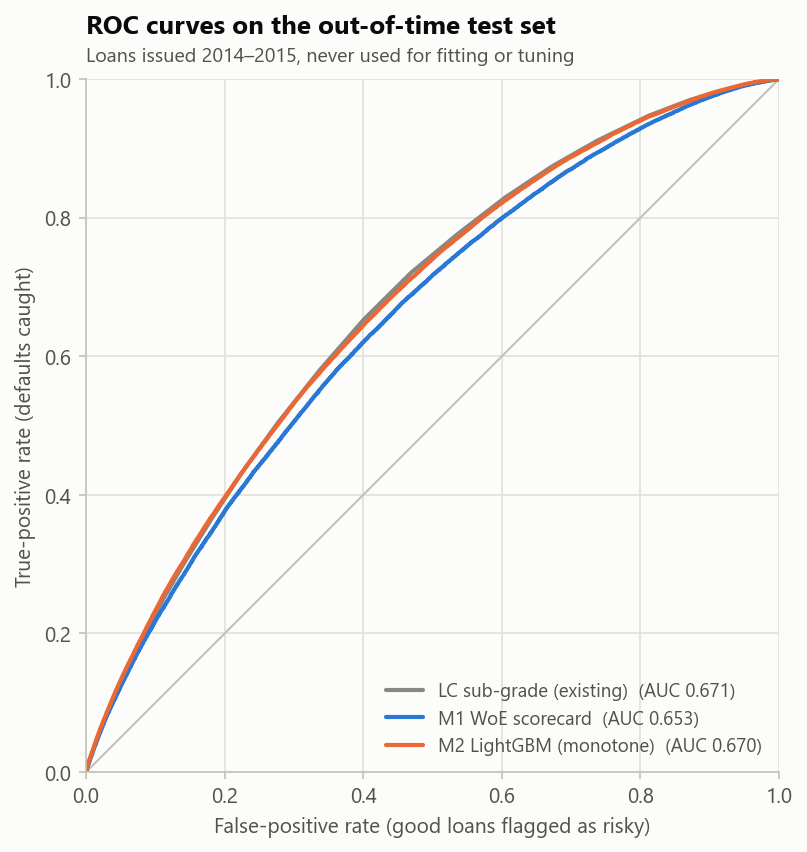

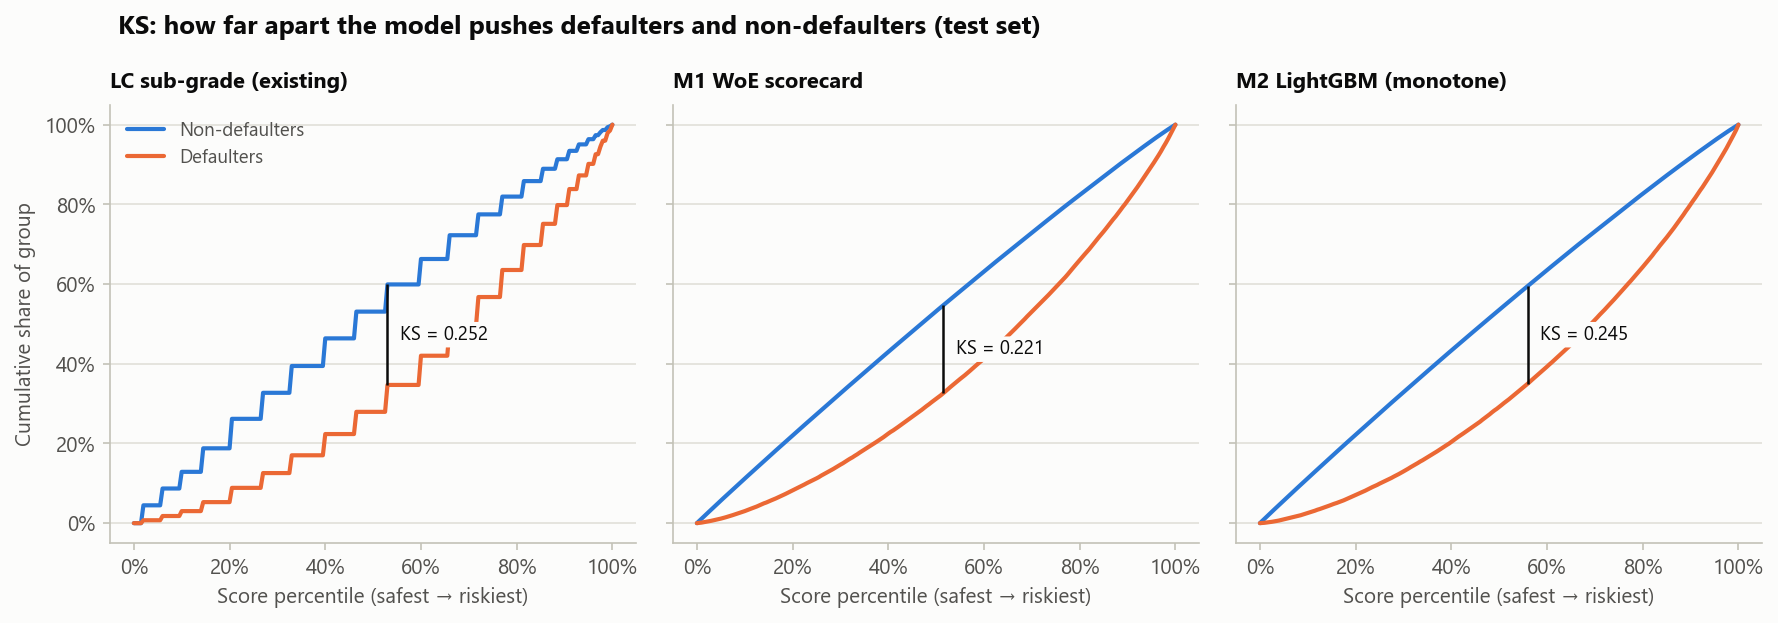

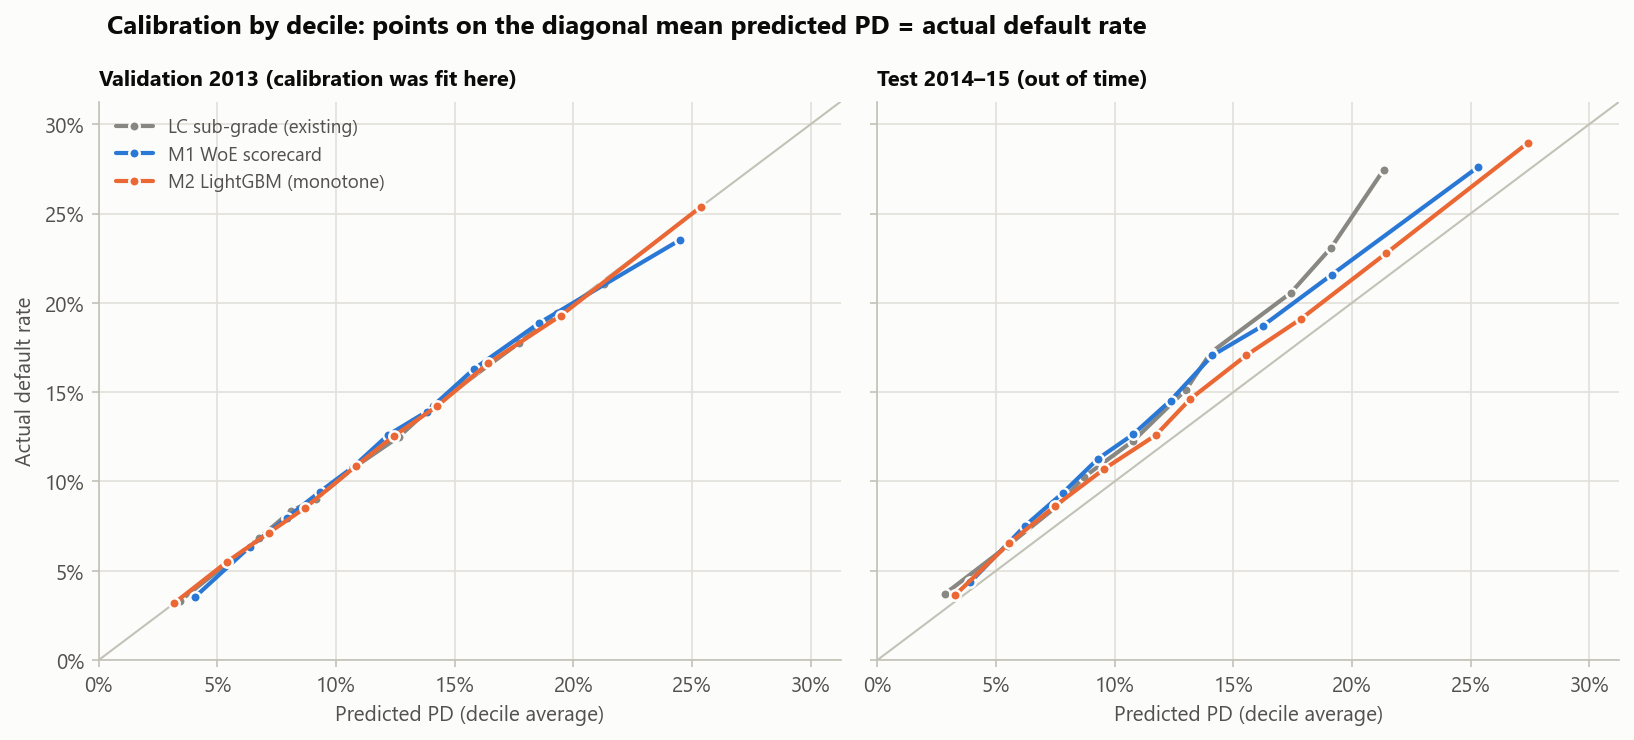

In [10]:
show("roc.png")
show("ks.png")
show("calibration.png")

**Reading the benchmark:** on 2013, both models beat LendingClub's grade; on 2014–15, M2 and the grade are a **statistical tie**
(the bootstrap CI for the AUC difference includes 0). M2 still has the best-calibrated probabilities (lowest Brier score), and the profit layer runs on probabilities.

A slice of the scorecard (points per FICO bin; 600 points = 50:1 good:bad odds, +20 points doubles the odds):

In [11]:
card = pd.read_csv(METRICS / "scorecard.csv")
display(card[card["feature"] == "fico_mid"][["bin", "n", "bad_rate", "woe", "points"]])

,bin,n,bad_rate,woe,points
0,<= 672,10596,0.2015,-0.5700,48.2378
1,"(672, 677]",4316,0.1525,-0.2320,55.4389
2,"(677, 687]",8792,0.1512,-0.2216,55.6600
3,"(687, 692]",4353,0.1374,-0.1103,58.0317
4,"(692, 702]",7882,0.1250,-0.0011,60.3585
5,"(702, 712]",6300,0.1141,0.1018,62.5504
6,"(712, 722]",5454,0.0975,0.2771,66.2857
7,"(722, 737]",6286,0.0920,0.3424,67.6765
8,"(737, 757]",5749,0.0703,0.6345,73.8991
9,> 757,6309,0.0485,1.0280,82.2827


## Phase 6 — Profit decision layer

```
realized profit  = total payments × (1 − 1% servicing fee) − funded amount          (evaluation)
expected profit  = (1 − PD) · r_good[sub-grade] · amount − PD · L[grade] · amount    (decision)
```
`r_good` (return on a repaid loan) and `L` (loss on a defaulted loan) are estimated on 2010–12 only.
Policies are compared on **realized** profit on the 2014–15 test book. Approval rate = share of LendingClub's accepted book we keep.

In [12]:
pr = metrics("policy_results.json")
econ = pd.DataFrame({"r_good (repaid)": pr["economics"]["r_good_by_grade"],
                     "L (defaulted)": pr["economics"]["loss_rate_by_grade"]})
econ["break-even PD"] = econ["r_good (repaid)"] / (econ["r_good (repaid)"] + econ["L (defaulted)"])
display(econ)

,r_good (repaid),L (defaulted),break-even PD
A,0.0878,0.4384,0.1668
B,0.1509,0.4018,0.2730
C,0.1919,0.4002,0.3241
D,0.2316,0.3846,0.3759
E,0.2641,0.3901,0.4037
F,0.2801,0.4037,0.4096
G,0.3150,0.4037,0.4383


In [13]:
from credit_engine.profit import expected_profit
# example: a $10,000 grade-C loan (r_good and L from the table above) at two PDs
r, L = pr["economics"]["r_good_by_grade"]["C"], pr["economics"]["loss_rate_by_grade"]["C"]
for p in (0.10, 0.40):
    print(f"PD {p:.0%}: expected profit ${expected_profit(p, r, L, 10_000):,.0f}")

PD 10%: expected profit $1,327
PD 40%: expected profit $-450


In [14]:
table = pd.DataFrame(pr["test_policy_table"])
view = table[table["target_rate"].isin([0.7, 1.0])][["policy", "target_rate", "bad_rate", "total_profit",
                                                    "funded_usd", "return_on_funded"]]
display(view.assign(total_profit=lambda d: d["total_profit"] / 1e6, funded_usd=lambda d: d["funded_usd"] / 1e9)
            .rename(columns={"total_profit": "profit ($M)", "funded_usd": "lent ($B)"}))
for key in ["bootstrap_test_m2_pd_minus_grade", "bootstrap_test_m2_profit_minus_grade"]:
    b = pr[key]
    print(f"{key}: {b['profit_diff'] / 1e6:+.1f}M  (95% CI {b['ci_low'] / 1e6:.1f}M to {b['ci_high'] / 1e6:.1f}M)")

,policy,target_rate,bad_rate,profit ($M),lent ($B),return_on_funded
0,Approve all (LC's actual book),1.0000,0.1446,360.2471,5.6667,0.0636
11,Grade policy (existing),0.7000,0.1054,270.4236,4.0680,0.0665
12,M1 scorecard PD,0.7000,0.1096,293.0718,4.2040,0.0697
13,M2 LightGBM PD,0.7000,0.1054,292.8806,4.0565,0.0722
14,M2 expected profit,0.7000,0.1444,315.3616,4.7095,0.0670
15,Grade-PD expected profit,0.7000,0.1514,314.4526,4.9607,0.0634


bootstrap_test_m2_pd_minus_grade: +22.5M  (95% CI 20.1M to 24.7M)
bootstrap_test_m2_profit_minus_grade: +44.9M  (95% CI 41.7M to 47.9M)


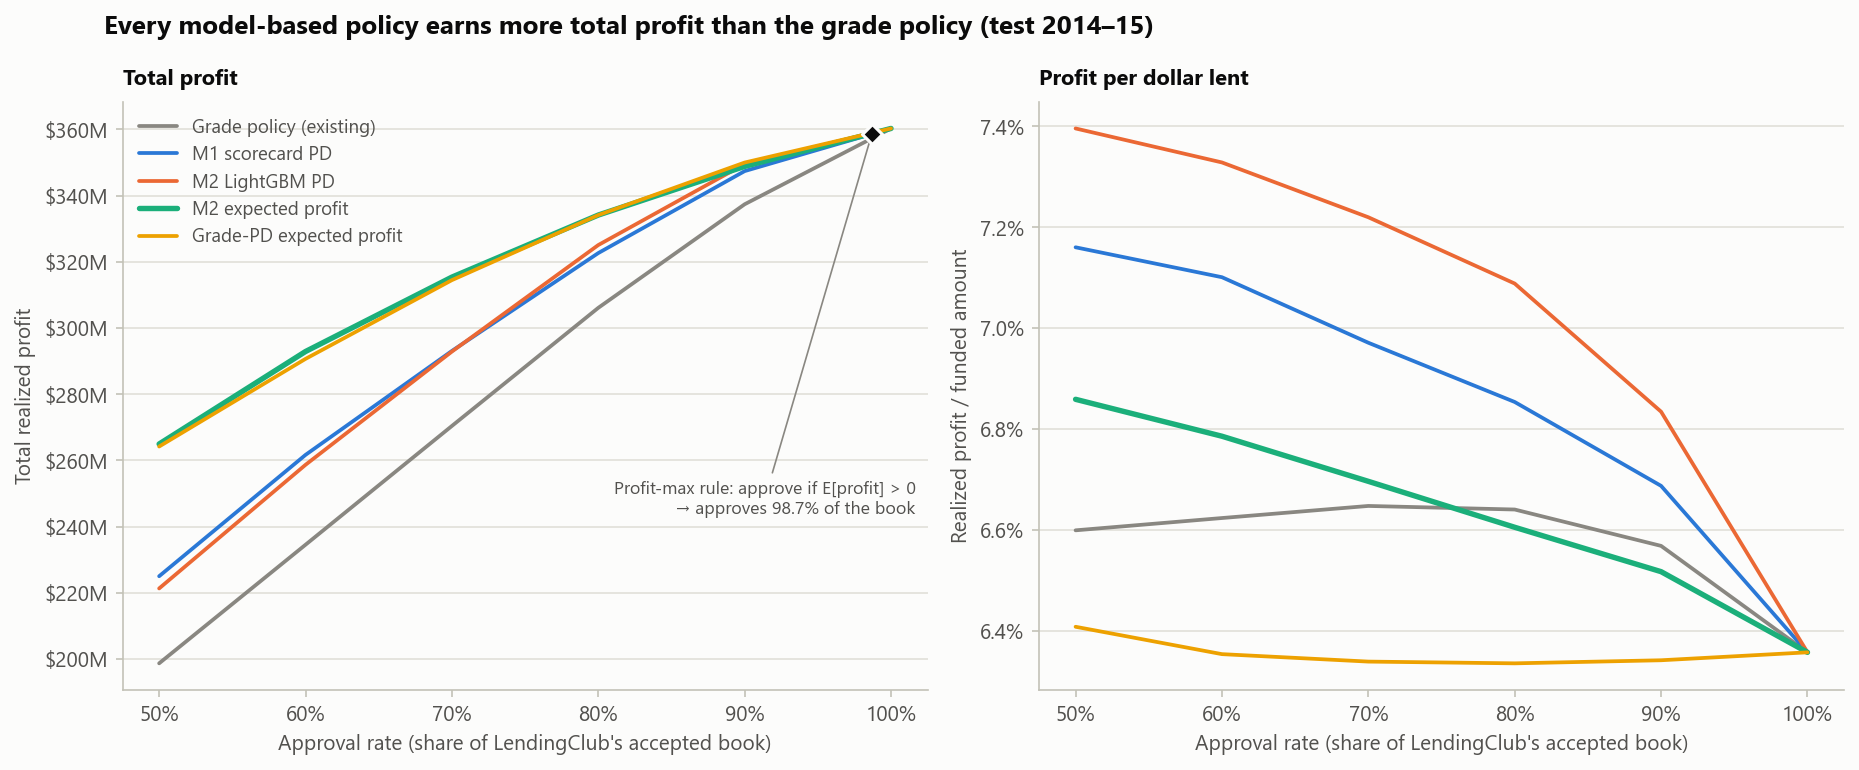

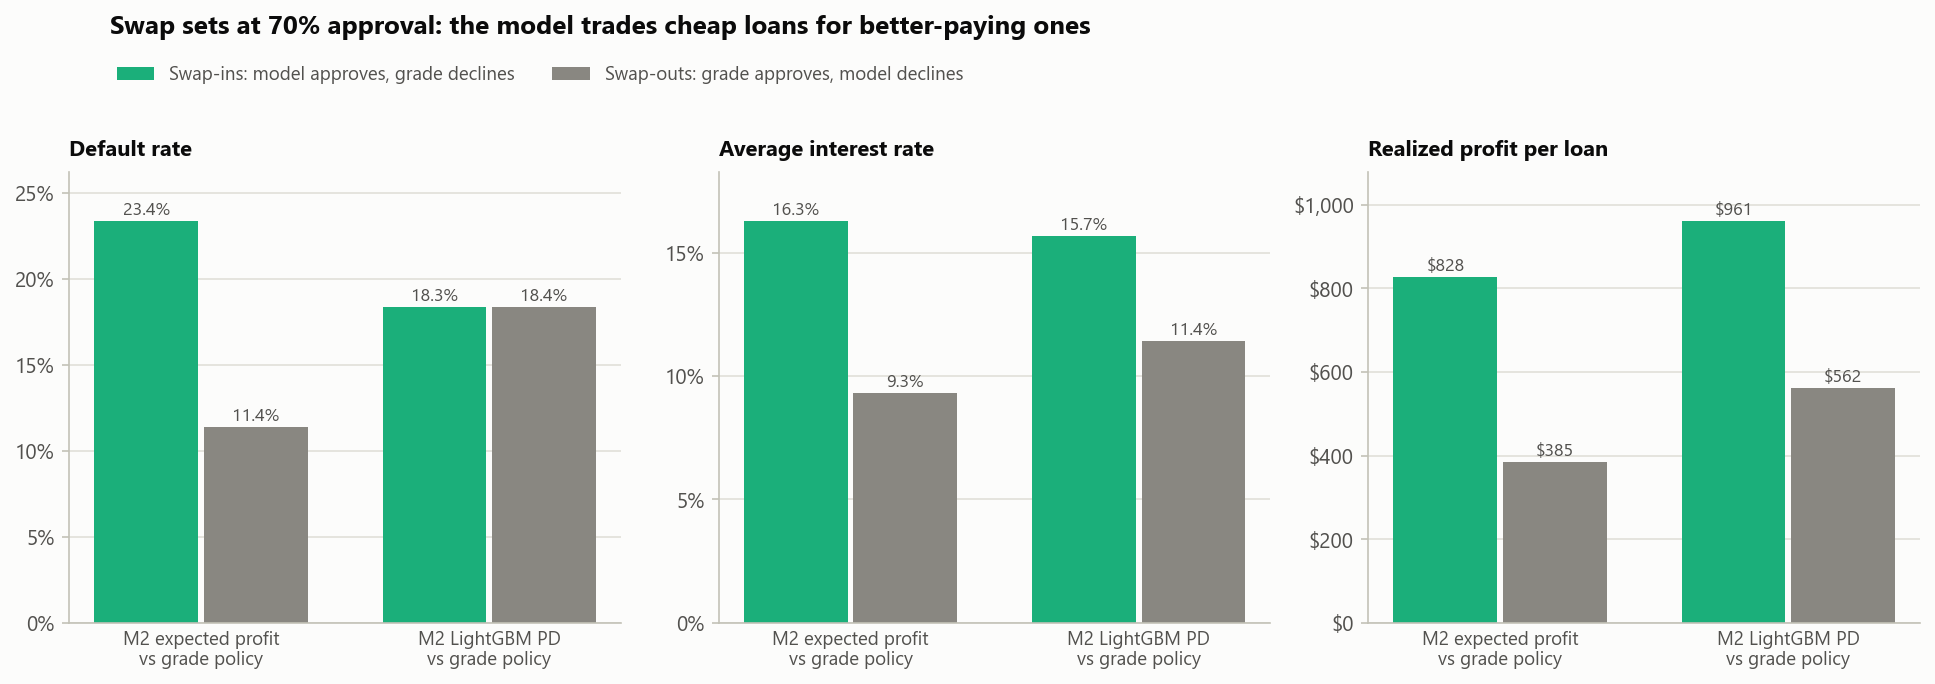

,comparison,group,n_loans,bad_rate,avg_int_rate,profit_per_loan
0,M2 expected profit vs grade policy,"swap-in (model approves, grade declines)",101393,0.2337,16.2914,827.8488
1,M2 expected profit vs grade policy,"swap-out (grade approves, model declines)",101393,0.1140,9.2961,384.6428
2,M2 expected profit vs grade policy,both approve,210357,0.1013,10.0107,"1,100.1465"
3,M2 LightGBM PD vs grade policy,"swap-in (model approves, grade declines)",56187,0.1835,15.6843,961.4938
4,M2 LightGBM PD vs grade policy,"swap-out (grade approves, model declines)",56187,0.1837,11.4230,561.8105
5,M2 LightGBM PD vs grade policy,both approve,255563,0.0882,9.4167,934.6312


In [15]:
show("profit_curve.png")
show("swap_set.png")
display(pd.DataFrame(pr["swap_set"])[["comparison", "group", "n_loans", "bad_rate", "avg_int_rate", "profit_per_loan"]])

**Two separate wins:**
1. **Ranking by M2's PD** earns more with the *same* volume, capital and bad rate: in the swap set, both groups default at the same rate, but M2's picks pay higher interest. M2 finds mispriced loans.
2. **Ranking by expected profit** earns the most, but lends more capital into riskier, larger loans; the same rule with the grade-based PD earns almost as much, so that gain is mostly the decision rule.

Sensitivity: losses ±20% and $0–100 cost per loan.

In [16]:
sens = pd.DataFrame(pr["sensitivity"])
display(sens[["loss_rate_multiplier", "fixed_cost_per_loan", "best_policy_at_rate", "m2_profit_minus_grade",
              "profit_m2_pd_at_70pct", "profit_grade_at_70pct"]])
print("Model policy beats grade in every scenario:", pr["sensitivity_ranking_holds"])

,loss_rate_multiplier,fixed_cost_per_loan,best_policy_at_rate,m2_profit_minus_grade,profit_m2_pd_at_70pct,profit_grade_at_70pct
0,0.8000,0,b0_profit,"66,547,918.6664","323,370,094.0002","300,599,137.4407"
1,0.8000,50,b0_profit,"66,547,918.6664","307,782,594.0002","285,011,637.4407"
2,0.8000,100,b0_profit,"66,547,918.6664","292,195,094.0002","269,424,137.4407"
3,1.0000,0,m2_profit,"44,937,993.0204","292,880,600.8450","270,423,593.0150"
4,1.0000,50,m2_profit,"44,937,993.0204","277,293,100.8450","254,836,093.0150"
5,1.0000,100,m2_profit,"44,937,993.0204","261,705,600.8450","239,248,593.0150"
6,1.2000,0,m2_profit,"26,055,269.9689","262,391,107.6897","240,248,048.5892"
7,1.2000,50,m2_profit,"26,055,269.9689","246,803,607.6897","224,660,548.5892"
8,1.2000,100,m2_profit,"26,055,269.9689","231,216,107.6897","209,073,048.5892"


Model policy beats grade in every scenario: True


## Phase 7 — Loss forecast vs actual

For each test quarter: forecast defaults = Σ PD, forecast net loss = Σ PD · L · amount, compared with what happened.
Benchmark = 2010–12 default rate by grade applied to each quarter's grade mix.

whole_book


,defaults_mape_pct,loss_mape_pct,defaults_mean_error_pct
Benchmark,7.5713,10.4768,-5.9436
M1,11.3309,10.5095,-11.3309
M2,6.8966,9.0286,-6.4856


approved_book


,defaults_mape_pct,loss_mape_pct,defaults_mean_error_pct
Benchmark,14.8483,32.1895,14.8483
M1,7.2766,11.2000,-5.9503
M2,8.5463,9.5011,-8.5463


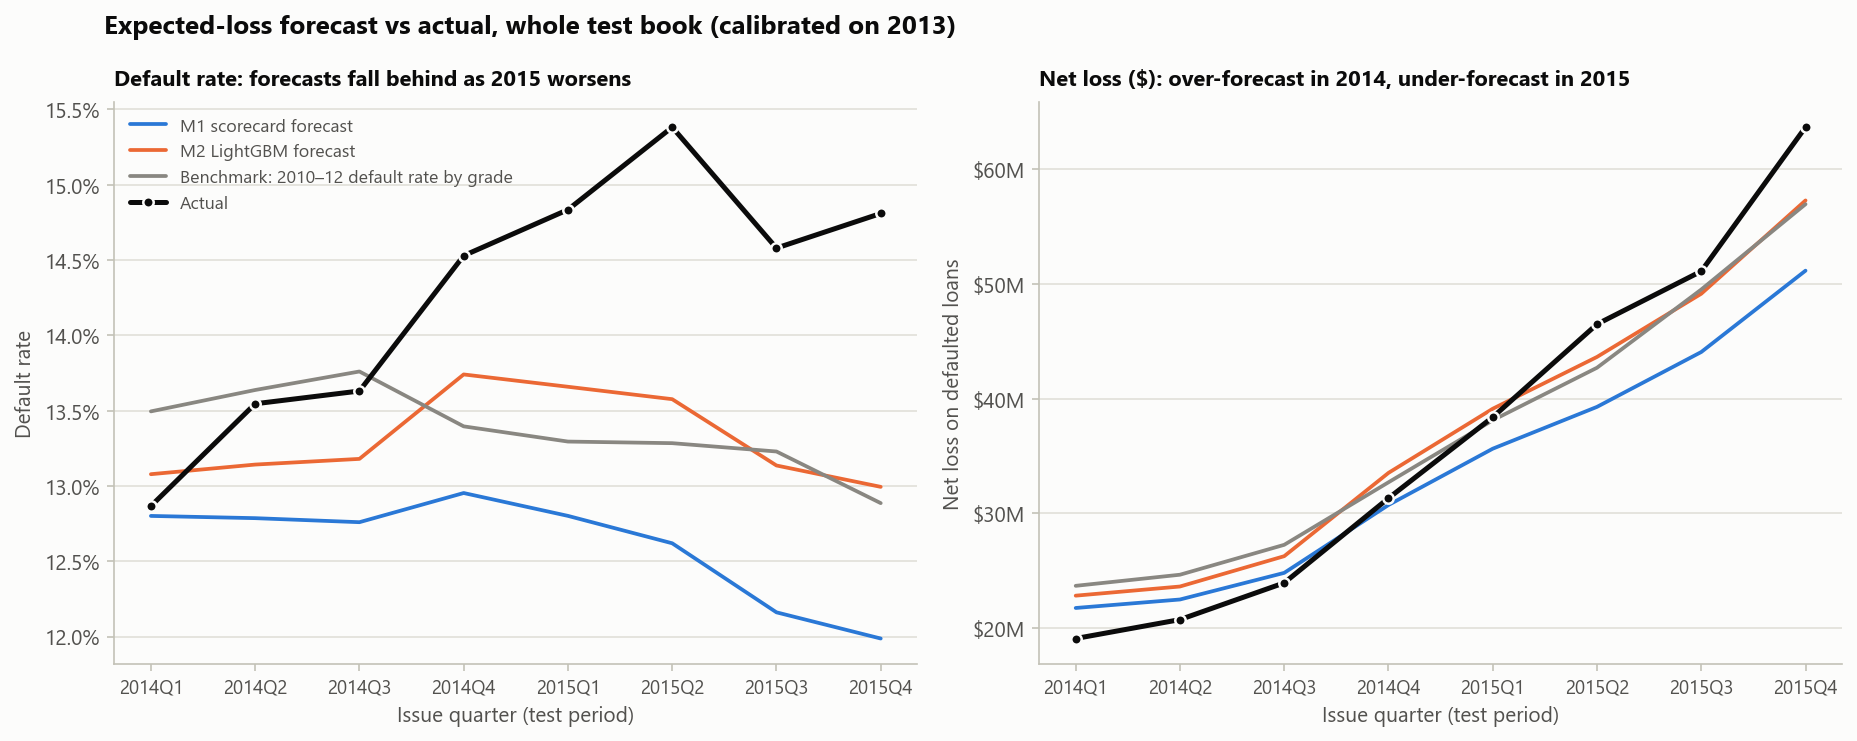

In [17]:
fc = metrics("forecast.json")
for book in ["whole_book", "approved_book"]:
    print(book)
    display(pd.DataFrame(fc[book]["summary"]).T[["defaults_mape_pct", "loss_mape_pct", "defaults_mean_error_pct"]])
show("forecast_vs_actual.png")

The totals look fine, but the quarterly errors trend: defaults are increasingly under-forecast through 2015 (drift).
On the approved book, M2 under-forecasts more: a policy that selects loans the model likes also concentrates the model's own errors (a selection effect).

## Phase 8 — Drift, weak spots, explainability

**PSI** compares the current score distribution with the training one (< 0.10 stable, 0.10–0.25 monitor, > 0.25 action). **CSI** applies the same test to each feature.

,variable,period,n_loans,psi,status
0,M2 calibrated PD,valid 2013,100422,0.0357,stable
1,M2 calibrated PD,2014Q1,34074,0.0769,stable
2,M2 calibrated PD,2014Q2,37881,0.0759,stable
3,M2 calibrated PD,2014Q3,40595,0.0734,stable
4,M2 calibrated PD,2014Q4,50020,0.1209,monitor
5,M2 calibrated PD,2015Q1,56568,0.1103,monitor
6,M2 calibrated PD,2015Q2,64222,0.1003,monitor
7,M2 calibrated PD,2015Q3,73567,0.0664,stable
8,M2 calibrated PD,2015Q4,88430,0.0555,stable


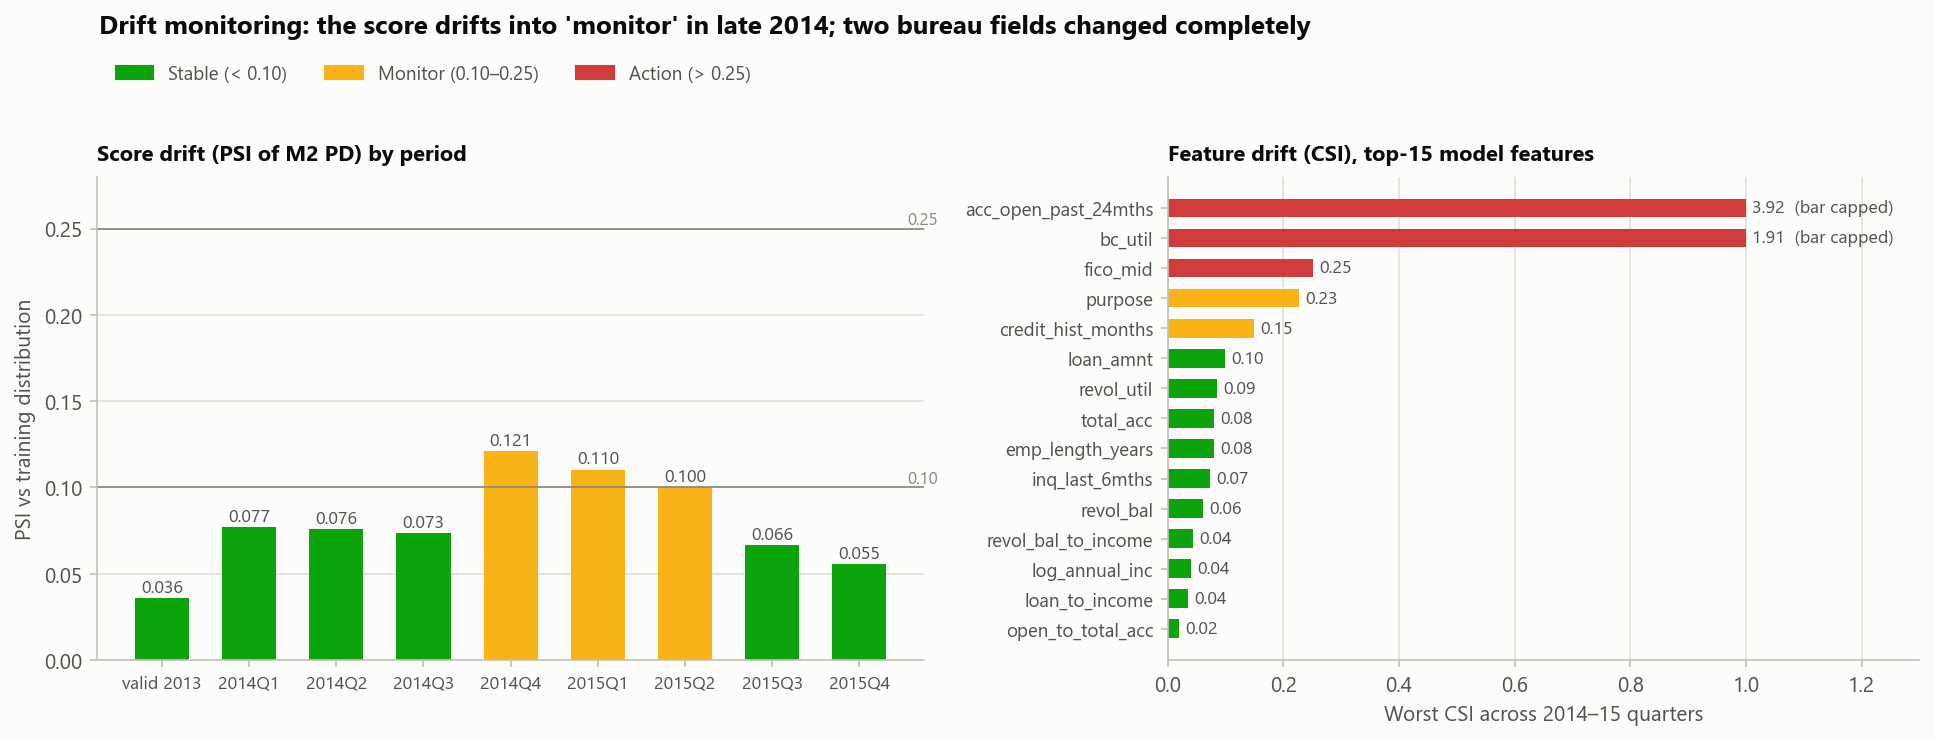

In [18]:
display(pd.read_csv(METRICS / "psi.csv"))
show("psi_by_quarter.png")

**Weak spots:** borrower segments where predicted and actual default rates differ by ≥ 2 pp, ranked by dollars at stake, with an early-warning check against 2013.

In [19]:
spots = pd.read_csv(METRICS / "weak_spots.csv")
display(spots[spots["flagged"]][["segment", "level", "n_loans", "actual_default_rate", "predicted_default_rate",
                                 "gap_pp", "est_dollar_impact", "valid_gap_pp", "same_direction_in_2013"]])
ms = metrics("monitoring_summary.json")
print(f"{ms['n_flagged_same_direction_in_2013']} of {ms['n_flagged_with_2013_data']} flagged segments were already "
      "under-predicted in the same direction in 2013 (below the flag threshold).")

,segment,level,n_loans,actual_default_rate,predicted_default_rate,gap_pp,est_dollar_impact,valid_gap_pp,same_direction_in_2013
0,home_ownership,RENT,191147,0.1717,0.1466,2.5097,"21,893,284.2083",1.0748,True
1,verification_status,Verified,122991,0.1779,0.1530,2.4900,"17,761,824.7134",0.0984,True
2,credit_history,5–10 yrs,68020,0.1690,0.1413,2.7623,"7,893,316.9122",1.0458,True
3,dti_band,30+,41753,0.2065,0.1683,3.8159,"7,189,721.5723",0.9652,True
4,dti_band,25–30,56610,0.1798,0.1572,2.2549,"6,576,530.8746",1.1350,True
5,income_quintile,Q1 (< $37k),73750,0.1996,0.1774,2.2174,"4,729,583.2224",1.9763,True
6,emp_length,missing,28565,0.2110,0.1820,2.9064,"3,448,798.5116",1.1304,True
7,credit_history,< 5 yrs,12480,0.1922,0.1645,2.7712,"1,209,026.0502",1.4776,True
8,purpose,major_purchase,8228,0.1412,0.1072,3.3985,"1,153,688.1435",1.3927,True
9,fico_band,780+,10375,0.0417,0.0301,1.1684,"734,661.6960",0.3222,True


12 of 12 flagged segments were already under-predicted in the same direction in 2013 (below the flag threshold).


**SHAP** explains each prediction feature by feature; the top risk-raising features become adverse-action style **reason codes** for declined applicants.

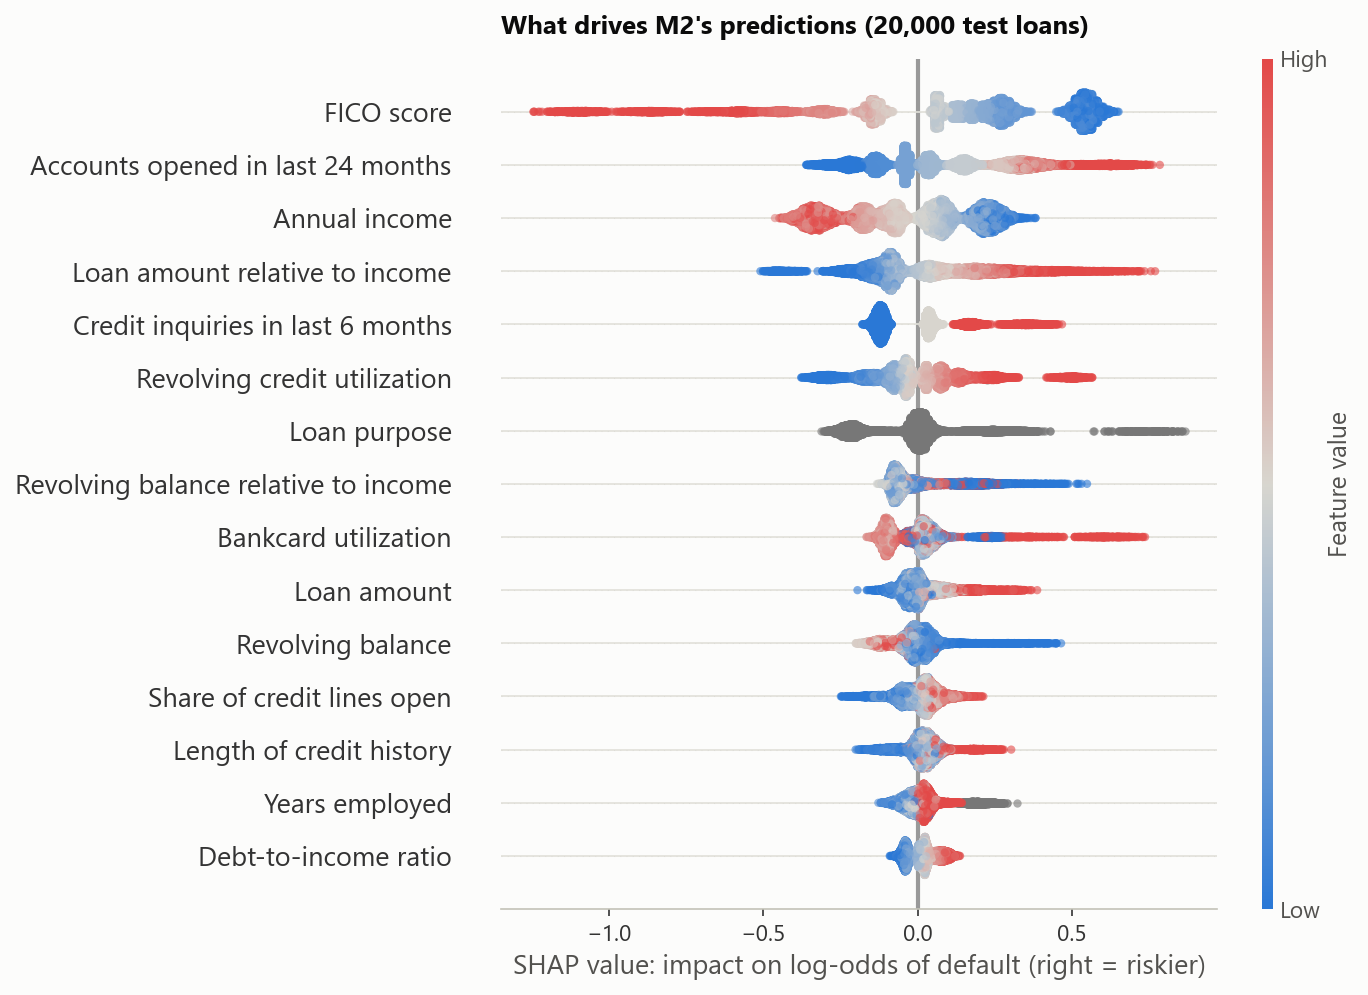

,id,sub_grade,loan_amnt,pd_m2,risk_factor_1,risk_factor_2,risk_factor_3,risk_factor_4
0,55191618,C2,"10,000.0000",0.2669,FICO score: 662,Accounts opened in last 24 months: 7,Credit inquiries in last 6 months: 2,Years employed: not reported
1,60825343,C1,"9,600.0000",0.1820,Accounts opened in last 24 months: 8,FICO score: 677,Loan purpose: other,Years employed: not reported
2,55997815,C2,"7,200.0000",0.1905,Credit inquiries in last 6 months: 4,FICO score: 677,Accounts opened in last 24 months: 5,Revolving balance relative to income: 0.06
3,61362087,D2,"15,000.0000",0.2250,Accounts opened in last 24 months: 9,FICO score: 687,"Loan amount: $15,000",Debt-to-income ratio: 29.8%
4,55080295,C1,"20,000.0000",0.2662,Accounts opened in last 24 months: 10,Loan amount relative to income: 0.38,FICO score: 697,"Loan amount: $20,000"


In [20]:
show("shap_summary.png")
display(pd.read_csv(METRICS / "reason_codes_examples.csv")[["id", "sub_grade", "loan_amnt", "pd_m2",
                                                           "risk_factor_1", "risk_factor_2", "risk_factor_3", "risk_factor_4"]])

## Conclusions

- A data-driven policy beats LendingClub's grade-based approvals on **realized profit**, even though the model only ties the grade on AUC, because it has better-calibrated probabilities and finds loans whose price overstates their risk.
- The result survives bootstrap resampling and loss/cost stress tests.
- Model risk is visible and manageable: the score drifts into "monitor" in late 2014, weak-spot segments were already leaning the wrong way in 2013, and every decline comes with reason codes.

**Limitations:** accepted loans only (no reject inference), simplified profit (no funding cost or time value), P2P installment-loan economics, one benign credit period, and loss rates by grade only.

Full tables: `reports/results.md` · Recommendation: `reports/business_memo.md` · Interactive: `streamlit run app/streamlit_app.py`